# Load Sentinel-3 data from the CDSE STAC catalog

This notebook shows an example how to load Sentinel-3 data from the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?.language=en).

### Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

The data can be accessed via S3, where key and secret can be obtained following the [CDSE access documentation to EO data via S3](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets). The store object will receive the key and secret upon initialization, as demonstrated below.

Now, we first import everything we need:

In [1]:
%%time
import xarray as xr
import matplotlib.pyplot as plt
from xcube.core.store import new_data_store, get_data_store_params_schema

CPU times: user 4.03 s, sys: 274 ms, total: 4.3 s
Wall time: 2.36 s


In [2]:
xr.set_options(display_expand_attrs=False)

Next store the credentials in a dictionary. 

In [3]:
credentials = dict(
    key="xxx",
    secret="xxx",
)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?language=en):

- **`stac-cdse-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-cdse`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal anaylsis-ready data cubes 

In the following, we will first demonstrate how to use the `stac-cdse-ardc` store. To view the parameters to initialize the data store instance, execute the following cell. 

> **Note:**  
> Access requires your S3 `key` and `secret`.

In [4]:
%%time
store_params = get_data_store_params_schema("stac-cdse-ardc")
store_params

CPU times: user 353 ms, sys: 47.1 ms, total: 400 ms
Wall time: 411 ms


In [5]:
%%time
store = new_data_store("stac-cdse-ardc", **credentials)

CPU times: user 20.1 ms, sys: 3.08 ms, total: 23.2 ms
Wall time: 1.42 s


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [6]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 34 μs, sys: 3 μs, total: 37 μs
Wall time: 41.5 μs


['sentinel-2-l2a',
 'sentinel-2-l1c',
 'sentinel-3-syn-2-syn-ntc',
 'sentinel-3-sl-2-lst-ntc']

Below, the parameters for the `open_data` method can be viewed for aspecific data ID.

In [7]:
%%time
open_params = store.get_open_data_params_schema("sentinel-3-syn-2-syn-ntc")
open_params

CPU times: user 8.57 ms, sys: 2.05 ms, total: 10.6 ms
Wall time: 9.91 ms


The store supports the collection `"sentinel-3-syn-2-syn-ntc"`, from which ARDC can be built as shown in the next cell. 

In [8]:
%%time
ds = store.open_data(
    data_id="sentinel-3-syn-2-syn-ntc",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["syn_Oa01_reflectance", "syn_Oa02_reflectance"],
    add_error_bands=False,
)
ds

CPU times: user 13 s, sys: 15.2 s, total: 28.2 s
Wall time: 2min 53s


<xarray.Dataset> Size: 152MB
Dimensions:       (time: 2, lat: 1336, lon: 1782)
Coordinates:
  * time          (time) datetime64[ns] 16B 2020-07-31T09:50:25.109021 2020-0...
  * lat           (lat) float64 11kB 55.0 55.0 54.99 54.99 ... 52.01 52.0 52.0
  * lon           (lon) float64 14kB 8.001 8.003 8.006 8.008 ... 12.0 12.0 12.0
    spatial_ref   int64 8B 0
Data variables:
    SDR_Oa01      (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa01_err  (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02      (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02_err  (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (17)

We can plot the spectral band 0 from the  OLCI Instrument as an example.

CPU times: user 4.24 s, sys: 2.87 s, total: 7.11 s
Wall time: 15.9 s


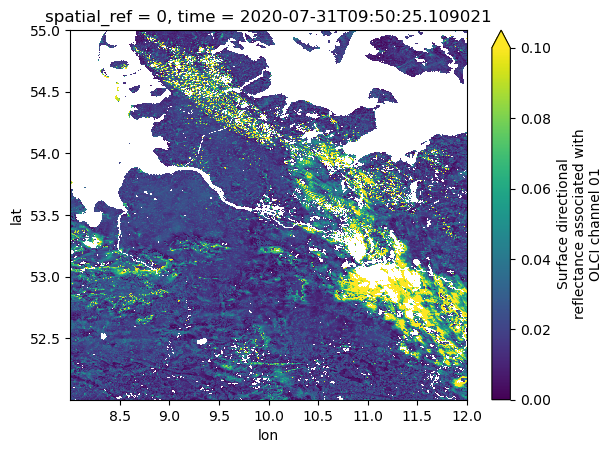

In [9]:
%%time
ds.SDR_Oa01.isel(time=-2).plot(vmin=0.0, vmax=0.1)

Next, we retrieve ARDC from the Sentinel-3 SLSTR Land Surface Temperature collection (`"sentinel-3-sl-2-lst-ntc"`).

In [10]:
%%time
ds = store.open_data(
    data_id="sentinel-3-sl-2-lst-ntc",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
)
ds

CPU times: user 1min 32s, sys: 53 s, total: 2min 25s
Wall time: 4min 59s


<xarray.Dataset> Size: 86MB
Dimensions:      (time: 4, lat: 1336, lon: 1782)
Coordinates:
  * time         (time) datetime64[ns] 32B 2020-07-31T09:50:25.108909 ... 202...
  * lat          (lat) float64 11kB 55.0 55.0 54.99 54.99 ... 52.01 52.0 52.0
  * lon          (lon) float64 14kB 8.001 8.003 8.006 8.008 ... 12.0 12.0 12.0
    spatial_ref  int64 8B 0
Data variables:
    mask         (time, lat, lon) uint8 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    LST          (time, lat, lon) float64 76MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (19)

CPU times: user 10.4 s, sys: 3.55 s, total: 14 s
Wall time: 14.3 s


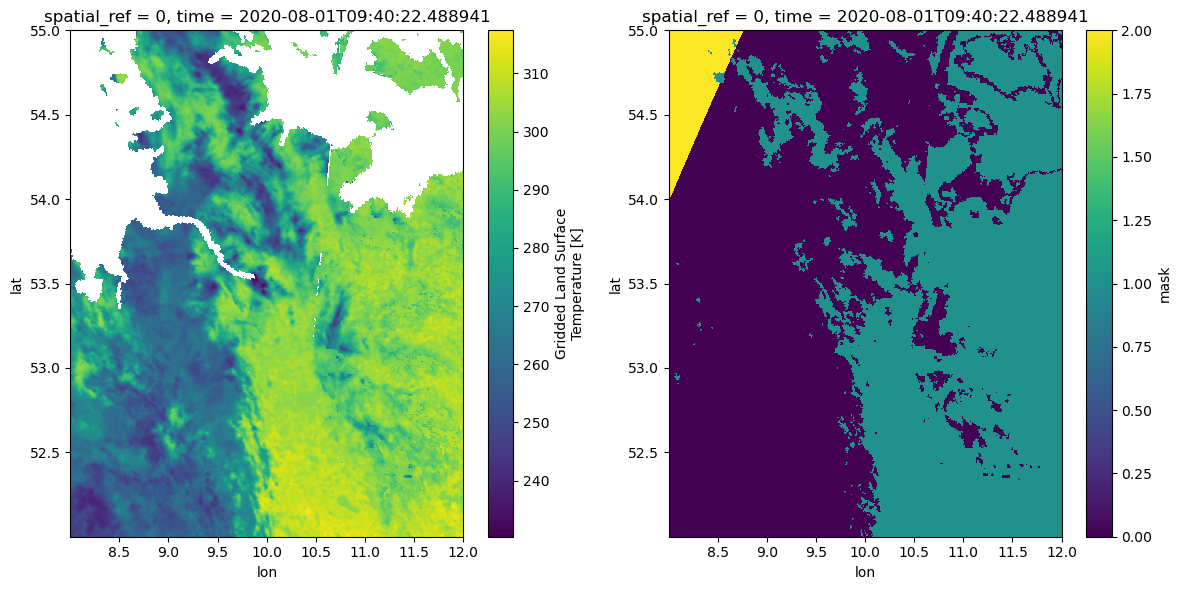

In [11]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ds.LST.isel(time=-2).plot(ax=ax[0])
ds.mask.isel(time=-2).plot(ax=ax[1])
plt.tight_layout()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [12]:
%%time
store_params = get_data_store_params_schema("stac-cdse")
store_params

CPU times: user 38 μs, sys: 22 μs, total: 60 μs
Wall time: 64.4 μs


To initialize the CDSE STAC data store, execute the following cell.

In [13]:
%%time
store = new_data_store("stac-cdse", **credentials)

CPU times: user 25.4 ms, sys: 29.4 ms, total: 54.7 ms
Wall time: 243 ms


Below, the parameters for the `open_data` method can be viewed.

In [14]:
%%time
open_params = store.get_open_data_params_schema()
open_params

CPU times: user 29 μs, sys: 17 μs, total: 46 μs
Wall time: 50.8 μs


If we specify the data ID, we obtain more precise parameters for opening and accessing that specific dataset.

In [15]:
data_id = (
    "collections/sentinel-3-syn-2-syn-ntc/items/S3B_SY_2_SYN____20250706T233058_"
    "20250706T233358_20250708T043306_0179_108_258_3420_ESA_O_NT_002"
)
store.get_open_data_params_schema(data_id=data_id)

We can now open the data set associated with the data ID. Note that first we do not apply any rectification. Thus the data is shown on the irregular native grid. 

In [16]:
%%time
ds = store.open_data(data_id, apply_rectification=False, add_error_bands=False)
ds

CPU times: user 1.83 s, sys: 2.96 s, total: 4.79 s
Wall time: 17.5 s


<xarray.Dataset> Size: 4GB
Dimensions:   (y: 4091, x: 4865)
Coordinates:
    lat       (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    lon       (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables: (12/26)
    SDR_S1N   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2O   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3N   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3O   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...        ...
    SDR_Oa11  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa12  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa16  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa17  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (15)

CPU times: user 2.24 s, sys: 3.43 s, total: 5.67 s
Wall time: 20.9 s


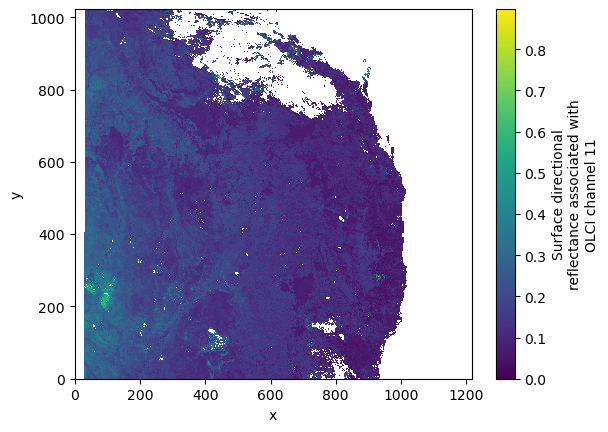

In [17]:
%%time
ds.SDR_Oa11[::4, ::4].plot()

In the next step we show the dataset on a regular grid, where the [xcube's rectification algorithm](https://xcube.readthedocs.io/en/latest/rectify.html) is applied. Note that showing the data on a regular grid is the default. 

In [18]:
%%time
ds = store.open_data(data_id)
ds

CPU times: user 4.72 s, sys: 6.27 s, total: 11 s
Wall time: 34.6 s


<xarray.Dataset> Size: 13GB
Dimensions:       (lon: 6020, lat: 5275)
Coordinates:
  * lon           (lon) float64 48kB 140.9 140.9 140.9 ... 157.0 157.0 157.0
  * lat           (lat) float64 42kB -21.05 -21.06 -21.06 ... -34.52 -34.53
    spatial_ref   int64 8B 0
Data variables: (12/52)
    SDR_S1N       (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1N_err   (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O       (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O_err   (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N       (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N_err   (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...            ...
    SDR_Oa17      (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa17_err  (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18      (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18_err  (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21      (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21_err  (lat, lon) float64 254MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (15)

CPU times: user 39.2 s, sys: 18.8 s, total: 58 s
Wall time: 20.9 s


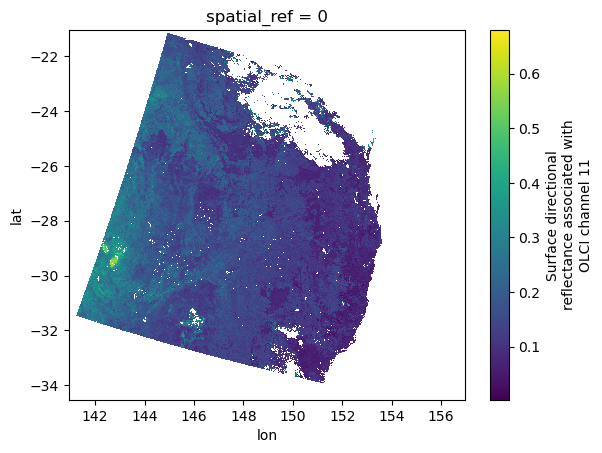

In [19]:
%%time
ds.SDR_Oa11[::4, ::4].plot()

In [28]:
data_id = (
    "collections/sentinel-3-sl-2-lst-ntc/items/S3B_SL_2_LST____20260217T102917_"
    "20260217T103217_20260218T165304_0180_117_008_2520_ESA_O_NT_004"
)
store.get_open_data_params_schema(data_id=data_id)

In [29]:
%%time
ds = store.open_data(
    data_id, 
    apply_rectification=False,
    apply_geo_orthorectification=False,
)
ds

CPU times: user 498 ms, sys: 686 ms, total: 1.18 s
Wall time: 4.08 s


<xarray.Dataset> Size: 45MB
Dimensions:  (y: 1200, x: 1500)
Coordinates:
    lat      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    lon      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    LST      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    mask     (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (17)

CPU times: user 706 ms, sys: 95 ms, total: 801 ms
Wall time: 739 ms


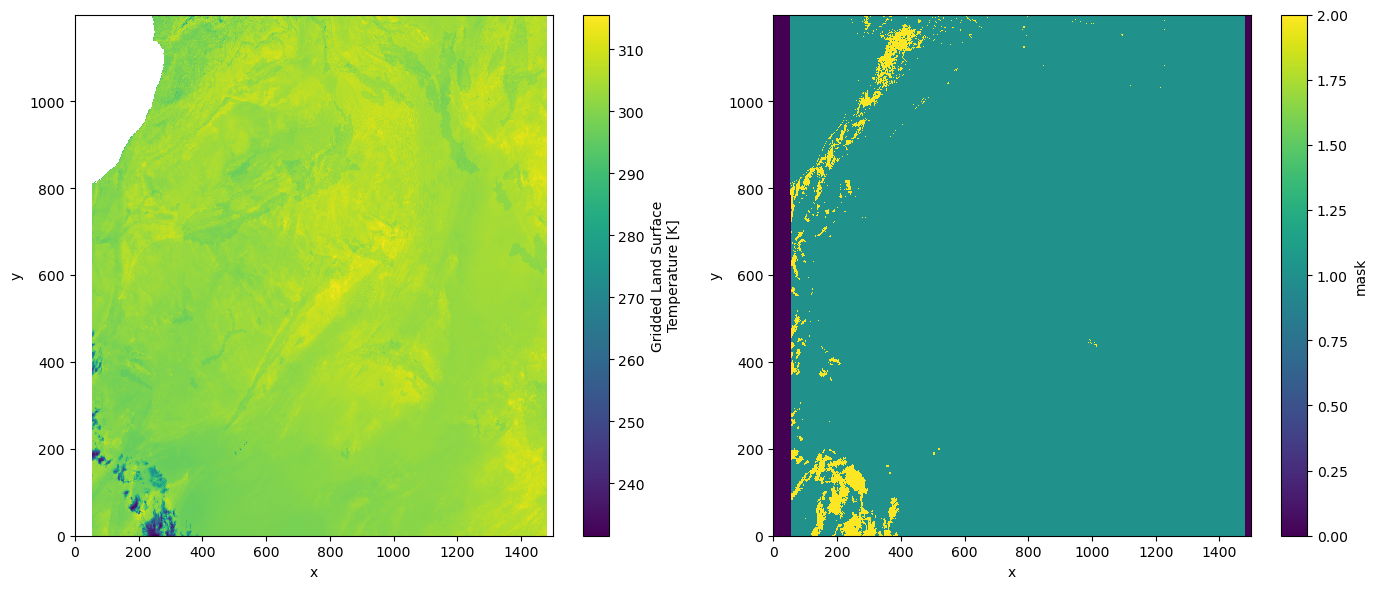

In [30]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.mask.plot(ax=ax[1])
plt.tight_layout()

In [31]:
%%time
ds = store.open_data(data_id)
ds

CPU times: user 3.39 s, sys: 1.46 s, total: 4.85 s
Wall time: 7.5 s


<xarray.Dataset> Size: 24MB
Dimensions:      (lon: 1751, lat: 1522)
Coordinates:
  * lon          (lon) float64 14kB -14.17 -14.16 -14.15 ... 2.856 2.866 2.876
  * lat          (lat) float64 12kB 31.5 31.5 31.49 31.48 ... 18.18 18.18 18.17
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon) float64 21MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    mask         (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (17)

CPU times: user 11 s, sys: 2.45 s, total: 13.5 s
Wall time: 4.44 s


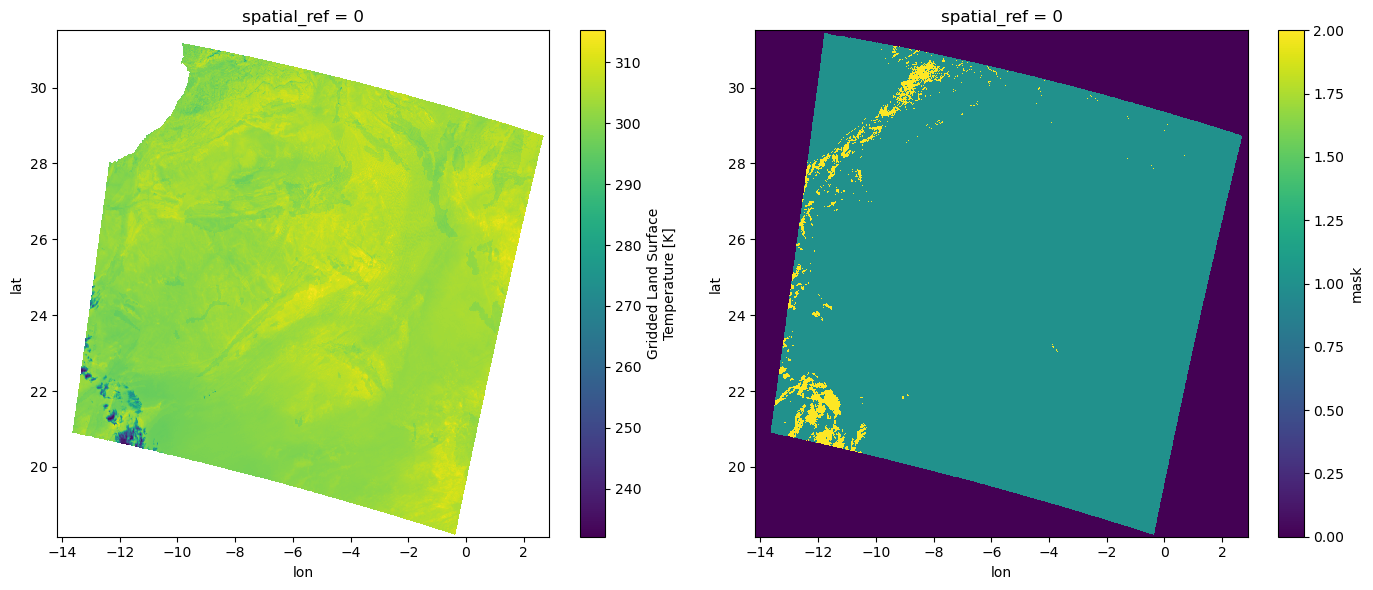

In [33]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.mask.plot(ax=ax[1])
plt.tight_layout()